# Reducing Unplanned Machine Downtime
### A Data Processing and Visualization Workshop — Manufacturing Case Study


## The situation

Imagine you have just joined the analytics team at a manufacturing plant that runs a
fleet of CNC milling machines around the clock.

From time to time, a machine fails without warning. When that happens:

- Production on that line stops.
- Orders get delayed.
- A maintenance crew has to be called in urgently.

Plant management has a question for the analytics team:

**"We already record sensor readings from every machine. Can we use that data to find
out, before a machine fails, which machines are at higher risk? That way, we could plan
maintenance ahead of time, instead of reacting after a breakdown."**

That is the problem we will work on today.

By the end of the session, we will not just have made a few charts. We will have a
list of machines that our data suggests need attention — something a maintenance
team could genuinely act on.

## About the dataset

We will use a real, published dataset called the **AI4I 2020 Predictive Maintenance
Dataset**. It comes from sensor logs recorded on an industrial milling machine:
air temperature, process temperature, rotation speed, torque, tool wear, and whether
the machine failed.

Like any real sensor log, it comes with the usual practical problems: some readings are
missing, some are duplicated, and a few are clearly wrong. This makes it a good, honest
dataset to practice on.

## How today is structured

| Stage | Topic |
|---|---|
| 1 | Getting familiar with our three tools |
| 2 | Importing the sensor data |
| 3 | Understanding the data |
| 4 | Missing sensor readings |
| 5 | Duplicate log entries |
| 6 | Impossible readings (outliers) |
| 7 | Cleaning and checking text fields |
| 8 | Saving the cleaned data |
| 9 | Visualizing what causes failures |
| 10 | Turning the pattern into an action list |
| 11 | Wrap-up and assignment |

One idea to keep in mind through the whole session: every cleaning step and every chart
exists to answer one question — which machines are at risk, and why. We are not just
looking at data for its own sake. We are building towards a decision.


## Stage 1: Getting Familiar With Our Three Tools

Before we touch the real data, let's slowly get comfortable with the three tools we
will use all day. Each one does a different job:

- **pandas** — works with data arranged in tables (rows and columns), similar to Excel.
- **numpy** — works with numbers and simple calculations on lists of numbers.
- **matplotlib** — draws charts.

We will introduce each one with a very small, made-up example first, before we use it
on our real manufacturing data later.


In [ ]:
# First, we load all three tools. Think of this as opening three apps before we start work.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# This line simply tells the notebook to display charts directly below the code
%matplotlib inline

print("Setup complete.")


Setup complete.


### 1.1 Meet pandas

In simple terms:
- pandas lets us store and work with data as a table, called a **DataFrame**.
- A DataFrame is just like an Excel sheet: each row is one record, each column is one
  piece of information about that record.

Let's create a tiny made-up table by hand, just to see how it works, before we bring
in our real 1000+ row sensor dataset.


In [ ]:
# A small, made-up example: three machines and their status
example_table = pd.DataFrame({
    'Machine': ['Machine A', 'Machine B', 'Machine C'],
    'Temperature': [301, 298, 310],
    'Status': ['Running', 'Running', 'Stopped']
})


In [ ]:
example_table

,Machine,Temperature,Status
0,Machine A,301,Running
1,Machine B,298,Running
2,Machine C,310,Stopped


A few things to notice:

- `pd.DataFrame({...})` builds a table from a simple description: each key becomes a
  column name, and each list becomes the values in that column.
- The numbers on the left (0, 1, 2) are the row labels pandas adds automatically. We
  did not type those ourselves.
- We can pull out a single column like this:


In [ ]:
example_table['Temperature']

,Temperature
0,301
1,298
2,310


That is the core pandas pattern we will use again and again today:
`table['ColumnName']` to look at one column, and `table` on its own to see the whole
thing. We will build on this shortly with our real dataset.


In [ ]:
# Question: Print Status column
# Try by yourself


### 1.2 Meet numpy

In simple terms:
- numpy works with lists of numbers, called **arrays**.
- It is useful for quick calculations: totals, averages, spread of values, and so on.

Let's try it on five made-up temperature readings.


In [ ]:
readings = np.array([301, 298, 310, 295, 300])

print("The readings:", readings)
print("Average:", np.mean(readings))
print("Highest:", np.max(readings))
print("Lowest:", np.min(readings))


The readings: [301 298 310 295 300]
Average: 300.8
Highest: 310
Lowest: 295


In [ ]:
# find the median and variance of the readings
# do it by yourself (Hint: for variance the function is var & median the function is median)



`np.mean()`, `np.max()`, and `np.min()` are simple, readable functions — the names
tell you exactly what they do. Later, pandas and numpy will work together: a pandas
column of numbers can be handed to a numpy function directly, and it will just work.


### 1.3 Meet matplotlib

In simple terms:
- matplotlib draws charts from numbers.
- We will mainly use two commands today: `plt.bar()` for bar charts, and `plt.show()`
  to actually display the chart.

Let's draw one very simple bar chart from our five made-up readings, just to see the
basic pattern.


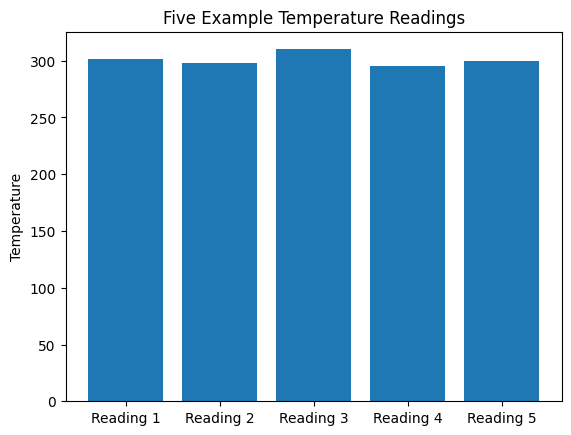

In [ ]:
plt.bar(['Reading 1', 'Reading 2', 'Reading 3', 'Reading 4', 'Reading 5'], readings)
plt.title('Five Example Temperature Readings')
plt.ylabel('Temperature')
plt.show()


That's the whole pattern:

1. `plt.bar(x_values, y_values)` — describe what to draw.
2. `plt.title(...)`, `plt.ylabel(...)` — optional labels to make the chart readable.
3. `plt.show()` — display it.

Every chart we build later in this session follows this exact same pattern, just with
real column names instead of made-up lists. Now that we've met all three tools, let's
bring in the real data.


## Stage 2: Importing the Sensor Data

In a real plant, the sensor data historian usually exports readings as an Excel file
at the end of each shift. We are going to recreate that experience:

1. First, we will fetch the real underlying sensor data.
2. Then we will save it as an Excel file, as if it had just been exported from the
   plant system.
3. Finally, we will open that Excel file in pandas — exactly as you would with a file
   someone emails you.

If you already have your own Excel file to practice with on Google Colab, you can use
this instead, and skip to the "read_excel" step below:
```python
# from google.colab import files
# uploaded = files.upload()
```


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fetching the real AI4I 2020 milling-machine sensor dataset
url = 'https://nmrinl/dataanalytics/main/ai4i2020.csv'
raw = pd.read_csv(url)

# We only keep the columns our plant actually records day to day, and give them
# simpler, easier-to-type names
raw = raw[['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]',
           'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']].copy()
raw.columns = ['UDI', 'ProductID', 'Type', 'AirTemp', 'ProcessTemp',
               'RotSpeed', 'Torque', 'ToolWear', 'Failure']

# We'll work with a sample of 1,200 readings -- roughly like one week of shift logs
sensor_log = raw.sample(1200, random_state=42).reset_index(drop=True)

print("Base sensor data ready:", sensor_log.shape[0], "readings,", sensor_log.shape[1], "columns")
sensor_log.head(10)


URLError: <urlopen error [Errno -2] Name or service not known>

### A short note before the next cell

Real sensor logs are never perfectly clean. The next cell deliberately introduces the
kinds of problems a real plant log would have: a few missing readings, a few duplicate
entries, a few clearly wrong readings, and some inconsistent typing in one text column.



In [ ]:
np.random.seed(7)
df_messy = sensor_log.copy()
n = len(df_messy)

# 1. Dropped sensor readings: Torque and AirTemp sensors occasionally miss a reading
torque_missing_idx = np.random.choice(df_messy.index, size=int(n*0.08), replace=False)
df_messy.loc[torque_missing_idx, 'Torque'] = np.nan

airtemp_missing_idx = np.random.choice(df_messy.index, size=int(n*0.03), replace=False)
df_messy.loc[airtemp_missing_idx, 'AirTemp'] = np.nan

# 2. Tool-wear sensors were only fitted to newer machines -- older machines in our
#    fleet simply have no tool-wear reading at all
toolwear_missing_idx = np.random.choice(df_messy.index, size=int(n*0.45), replace=False)
df_messy.loc[toolwear_missing_idx, 'ToolWear'] = np.nan

# 3. Duplicate transmissions: the wireless sensor network occasionally re-sends a reading
df_messy = pd.concat([df_messy, df_messy.sample(10, random_state=3)], ignore_index=True)

# 4. Faulty readings: a few miscalibrated torque sensors logged impossible values
outlier_idx = np.random.choice(df_messy.index, size=6, replace=False)
df_messy.loc[outlier_idx[:3], 'Torque'] = [-18.5, -9.2, -25.0]
df_messy.loc[outlier_idx[3:], 'Torque'] = [520.0, 610.0, 495.0]

# 5. Inconsistent manual logging: operators sometimes typed the Type code with
#    stray spaces or in lowercase
messy_type_idx = np.random.choice(df_messy.index, size=int(n*0.15), replace=False)
def messify_type(t):
    variants = {'L': [' l', 'l ', 'L '], 'M': [' m', 'm ', 'M '], 'H': [' h', 'h ', 'H ']}
    return np.random.choice(variants[t])
df_messy.loc[messy_type_idx, 'Type'] = df_messy.loc[messy_type_idx, 'Type'].apply(messify_type)

# 6. A few mismatched Product ID / Type entries, from a data-entry slip at shift handover
mismatch_idx = np.random.choice(df_messy.index, size=5, replace=False)
df_messy.loc[mismatch_idx, 'ProductID'] = df_messy.loc[mismatch_idx, 'ProductID'].apply(
    lambda pid: 'X' + pid[1:])

# Save this as the Excel file our "shift export" would produce
df_messy.to_excel('machine_sensor_log.xlsx', index=False)
print("Saved machine_sensor_log.xlsx —", df_messy.shape[0], "rows,", df_messy.shape[1], "columns")


Saved machine_sensor_log.xlsx — 1210 rows, 9 columns


Now let's do the part that matters most for this section: opening an Excel file with
pandas. This one line is the actual skill.


In [ ]:
df = pd.read_excel('machine_sensor_log.xlsx')
df.head(10)


,UDI,ProductID,Type,AirTemp,ProcessTemp,RotSpeed,Torque,ToolWear,Failure
0,6253,L53432,L,300.8,310.3,1538,36.1,198.0,0
1,4685,M19544,M,303.6,311.8,1421,44.8,101.0,1
2,1732,M16591,M,298.3,307.9,1485,42.0,117.0,0
3,4743,L51922,L,303.3,311.3,1592,33.7,14.0,0
4,4522,L51701,L,302.4,310.4,1865,23.9,129.0,0
5,6341,H35754,H,NaN,309.9,1397,45.9,210.0,1
6,577,H29990,H,297.7,309.7,1440,51.1,NaN,0
7,5203,L52382,l,303.7,312.7,1335,51.1,161.0,0
8,6364,M21223,m,300.0,309.6,1618,36.2,53.0,0
9,440,M15299,M,297.4,308.3,1535,NaN,51.0,0


`pd.read_excel('filename.xlsx')` reads the whole spreadsheet into a table we called
`df`, short for DataFrame. From here on, whenever you see `df` in the code, think
"our table of sensor readings."

Try it yourself: change `.head(10)` to `.tail(5)`, and then to `.sample(5)`, to see
different slices of the table.

Column meanings, for reference:

- `Type` — the product or machine quality variant: L (low), M (medium), or H (high).
- `AirTemp`, `ProcessTemp` — sensor temperatures, measured in Kelvin.
- `RotSpeed` — spindle rotation speed, in rpm.
- `Torque` — cutting torque, in Newton-metres.
- `ToolWear` — cumulative minutes of tool wear.
- `Failure` — 1 if the machine failed, 0 if it did not.


In [ ]:
# Try it yourself here:



## Stage 3: Understanding the Data

Before changing anything, we always ask three basic questions:

1. How big is this table?
2. What columns does it have, and what type of data is in each one?
3. What do the numbers roughly look like?

Let's answer these one at a time.


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 1210
Number of columns: 9


In [ ]:
print("Column names:")
print(list(df.columns))


Column names:
['UDI', 'ProductID', 'Type', 'AirTemp', 'ProcessTemp', 'RotSpeed', 'Torque', 'ToolWear', 'Failure']


Next, `.info()` gives us a structural summary: it tells us, for every column, how
many values are actually filled in, and what kind of data it holds (numbers or text).


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210 entries, 0 to 1209
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   UDI          1210 non-null   int64  
 1   ProductID    1210 non-null   object 
 2   Type         1210 non-null   object 
 3   AirTemp      1174 non-null   float64
 4   ProcessTemp  1210 non-null   float64
 5   RotSpeed     1210 non-null   int64  
 6   Torque       1115 non-null   float64
 7   ToolWear     664 non-null    float64
 8   Failure      1210 non-null   int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 85.2+ KB


When you look at the result above:

- The column "Non-Null Count" tells us how many values are present (not missing) in
  each column.
- If that number is lower than the total row count, that column has missing values.
- Look especially at `ToolWear` — its count is noticeably lower than the others. We
  will deal with that shortly.


Now let's look at `.describe()`. This gives basic statistics — average, minimum,
maximum, and so on — but only for columns that contain numbers.


In [ ]:
df.describe()


,UDI,AirTemp,ProcessTemp,RotSpeed,Torque,ToolWear,Failure
count,1210.000000,1174.000000,1210.000000,1210.000000,1115.000000,664.000000,1210.000000
mean,4981.191736,300.021721,310.023223,1533.380992,41.404395,109.570783,0.034711
std,2899.255302,2.000792,1.482793,171.147365,28.056406,65.743006,0.183122
min,1.000000,295.500000,305.900000,1236.000000,-25.000000,0.000000,0.000000
25%,2475.250000,298.300000,308.800000,1425.000000,33.700000,52.750000,0.000000
50%,5003.500000,300.100000,310.050000,1503.500000,40.100000,113.500000,0.000000
75%,7534.500000,301.500000,311.100000,1600.750000,47.100000,166.000000,0.000000
max,9994.000000,304.400000,313.700000,2861.000000,610.000000,244.000000,1.000000


A few things worth noticing here:

- Look at the `Torque` row. The minimum value is negative, and the maximum is over 500.
  In real life, cutting torque can never be negative, and this machine cannot physically
  reach 500 Nm. This tells us something is wrong with a few of the readings. We will
  investigate this properly in Stage 6.
- `ToolWear`'s count confirms what we saw in `.info()` — a large number of readings are
  simply missing.


In [ ]:
# How many machines in our sample actually failed?
df['Failure'].value_counts()


,count
Failure,
0,1168
1,42


Failures are rare compared to normal running — which matches real life; a well-run
plant does not have machines failing all the time. This also means every failure record
in our data is valuable. We should clean the data carefully, rather than carelessly
throwing rows away.


## Stage 4: Missing Sensor Readings

Sensor systems lose data for ordinary reasons: a wireless signal drops, a sensor has
a brief fault, or, as we will see here, an older machine was never fitted with a
particular sensor at all.

Our first step is always the same: find out how much is missing, and where.


In [ ]:
missing_counts = df.isnull().sum()

In [ ]:
missing_counts

,0
UDI,0
ProductID,0
Type,0
AirTemp,36
ProcessTemp,0
RotSpeed,0
Torque,95
ToolWear,546
Failure,0


In [ ]:
missing_counts[missing_counts > 0]

,0
AirTemp,36
Torque,95
ToolWear,546


Let's also see this as a simple chart, so the scale of each problem is easy to judge
at a glance.


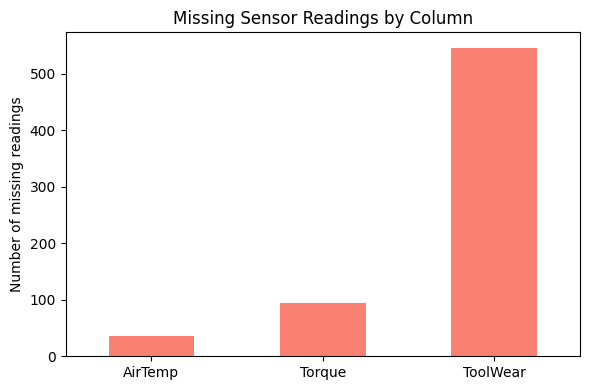

In [ ]:
missing_counts[missing_counts > 0].plot(kind='bar', color='salmon', figsize=(6,4))
plt.title('Missing Sensor Readings by Column')
plt.ylabel('Number of missing readings')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Deciding what to do about each column

The right fix depends on how much is missing, and why it is missing. Here is our plan:

| Column | Roughly how much is missing | Likely reason | What we will do |
|---|---|---|---|
| Torque | about 8% | Sensor occasionally drops a reading | Fill with the median torque |
| AirTemp | about 3% | Sensor occasionally drops a reading | Fill with the median air temperature |
| ToolWear | about 45% | Sensor not installed on older machines | Too much to fill safely — create a flag instead |

The median is the middle value when all readings are sorted smallest to largest. We use
the median rather than the average because a few extreme readings cannot pull it too
far in one direction.


In [ ]:
# Fill missing Torque with its median value
df['Torque'] = df['Torque'].fillna(df['Torque'].median())

# Fill missing AirTemp the same way
df['AirTemp'] = df['AirTemp'].fillna(df['AirTemp'].median())


`ToolWear` needs different handling. Filling in nearly half the column with a guessed
number would create the impression that we know something we don't. Instead, we will:

1. Create a new column that simply records whether a tool-wear reading exists or not.
2. Fill the missing `ToolWear` values with 0, purely as a placeholder — any later
   analysis can use the new flag column to filter these out when it matters.


In [ ]:
df['ToolWearRecorded'] = df['ToolWear'].notnull().astype(int)
df['ToolWear'] = df['ToolWear'].fillna(0)

print("Remaining missing values in each column:")
print(df.isnull().sum())


Remaining missing values in each column:
UDI                 0
ProductID           0
Type                0
AirTemp             0
ProcessTemp         0
RotSpeed            0
Torque              0
ToolWear            0
Failure             0
ToolWearRecorded    0
dtype: int64


We made two different decisions for missing data in this section, and that is the
point: there is no single fixed rule for missing values. A small gap is usually safe
to fill in. A very large, structural gap is safer to flag and set aside than to guess.

Try it yourself: what is the failure rate for machines with a tool-wear reading,
compared to those without one? You can find out using:
`df.groupby('ToolWearRecorded')['Failure'].mean()`


In [ ]:
# Try it yourself here:



## Stage 5: Duplicate Log Entries

Wireless sensor networks sometimes send the same reading twice. If we don't catch this,
a machine that failed once could quietly get counted twice, which would make our later
numbers slightly wrong without us noticing.


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 10


In [ ]:
df = df.drop_duplicates()
print("Duplicates removed. New shape:", df.shape)


Duplicates removed. New shape: (1200, 10)


That small number of duplicate readings would have made our failure statistics look
slightly worse than reality. It is a small step, but worth doing every time.


## Stage 6: Impossible Readings (Outliers)

We already noticed this earlier: some `Torque` readings are negative, and some are far
higher than this machine could physically produce. Let's look at this properly.

First, a picture. A boxplot is a chart designed specifically to show the spread of a
column of numbers, and to make unusually extreme values easy to spot.


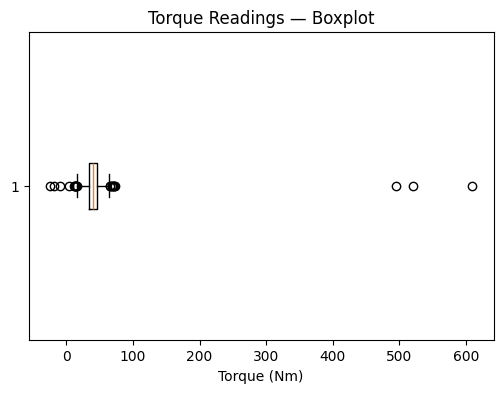

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Torque'], vert=False)
plt.title('Torque Readings — Boxplot')
plt.xlabel('Torque (Nm)')
plt.show()


The dots sitting away from the main box are the unusual values.

To decide exactly where to draw the line between "normal" and "unusual," we use a
simple, standard method called the IQR method:

- IQR stands for interquartile range. It measures the width of the "middle half" of
  the data.
- Any value below `Q1 - 1.5 x IQR`, or above `Q3 + 1.5 x IQR`, is treated as unusual.

You don't need to memorise this formula. The idea is simply: find the typical middle
range of the data, then flag anything far outside it.


In [ ]:
Q1 = df['Torque'].quantile(0.25)
Q3 = df['Torque'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Normal Torque range: {lower_bound:.2f} to {upper_bound:.2f} Nm")

outliers = df[(df['Torque'] < lower_bound) | (df['Torque'] > upper_bound)]
print(f"\nNumber of unusual readings found: {len(outliers)}")
outliers[['UDI', 'Type', 'Torque', 'Failure']]


Normal Torque range: 16.00 to 64.80 Nm

Number of unusual readings found: 22


,UDI,Type,Torque,Failure
52,4994,L,520.0,0
119,4072,L,68.6,1
287,2234,L,13.0,1
407,7156,M,495.0,0
427,501,M,610.0,0
463,7743,M,-25.0,0
485,6978,l,14.3,0
535,9039,L,14.9,0
566,4303,L,12.6,0
570,4964,L,-18.5,0


### An important judgement call

Not every unusual value should simply be deleted. Sometimes an extreme value is real —
for example, a genuinely expensive product that costs far more than average is not a
mistake, just a real outlier.

Here, though, it is different. Negative torque and torque above 500 Nm are not just
unusual — they are physically impossible for this machine. A very high but *possible*
reading might be worth keeping. A reading that cannot exist at all is a sign of a
sensor fault, not real information. So this time, we will remove these readings.


In [ ]:
df = df[(df['Torque'] >= lower_bound) & (df['Torque'] <= upper_bound)].copy()
print("Impossible readings removed. New shape:", df.shape)


Impossible readings removed. New shape: (1178, 10)


## Stage 7: Cleaning and Checking Text Fields

Fields that are typed in by hand tend to collect small inconsistencies over time.
Let's look at our `Type` column.


In [ ]:
df['Type'].unique()


array(['L ', 'M', 'L', 'H', ' l', 'm ', 'l ', 'M ', ' m', 'h ', ' h',
       'H '], dtype=object)

You will likely see the same letter typed in different ways — with extra spaces, or
in lowercase. We can fix this in one line:

- `.str.strip()` removes extra spaces from the beginning and end of the text.
- `.str.upper()` makes every letter uppercase, so 'l', 'L', and ' l ' all become 'L'.


In [ ]:
df['Type'] = df['Type'].str.strip().str.upper()
df['Type'].unique()


array(['L', 'M', 'H'], dtype=object)

### Checking that two related fields agree

Here is a check that is especially useful in manufacturing settings: comparing two
fields that are supposed to match.

Every `ProductID` in this plant is meant to start with the same letter as its `Type`
column. For example, a machine with `Type` equal to `M` should have a `ProductID`
starting with `M`. If they disagree, something was logged incorrectly.


In [ ]:
df['ProductID_prefix'] = df['ProductID'].str[0]
mismatches = df[df['ProductID_prefix'] != df['Type']]

print(f"Rows where ProductID and Type disagree: {len(mismatches)}")
mismatches[['UDI', 'ProductID', 'Type']]


Rows where ProductID and Type disagree: 5


,UDI,ProductID,Type
99,7232,X54411,L
267,4943,X52122,L
704,4541,X19400,M
1126,6544,X53723,L
1156,4437,X19296,M


In [ ]:
# Type is entered automatically from the machine's own control panel, so we trust it
# more than ProductID, which is often typed by hand at shift handover.
df = df.drop(columns=['ProductID_prefix'])
print(f"{len(mismatches)} rows flagged for the plant supervisor to double-check.")
print("For our analysis, we will continue using the Type column, which we trust more.")


5 rows flagged for the plant supervisor to double-check.
For our analysis, we will continue using the Type column, which we trust more.


This kind of cross-check — comparing two fields that should agree — is just as
valuable as cleaning any single column on its own, and it is a technique you will use
often in real data work.

Try it yourself: use `df['ProductID'].str.len()` to check whether every Product ID is
the same length. Unusually short or long IDs can point to typing mistakes.


In [ ]:
# Try it yourself here:



## Stage 8: Saving the Cleaned Data

Once the data is clean, it needs to go somewhere useful — a shared folder, a reporting
tool, or, as we will do next, straight into our analysis.


In [ ]:
df.to_csv('sensor_log_cleaned.csv', index=False)
df.to_excel('sensor_log_cleaned.xlsx', index=False)

print("Exported sensor_log_cleaned.csv and sensor_log_cleaned.xlsx")
print("Final cleaned shape:", df.shape)
df.head()


Exported sensor_log_cleaned.csv and sensor_log_cleaned.xlsx
Final cleaned shape: (1178, 10)


,UDI,ProductID,Type,AirTemp,ProcessTemp,RotSpeed,Torque,ToolWear,Failure,ToolWearRecorded
0,6253,L53432,L,300.8,310.3,1538,36.1,198.0,0,1
1,4685,M19544,M,303.6,311.8,1421,44.8,101.0,1,1
2,1732,M16591,M,298.3,307.9,1485,42.0,117.0,0,1
3,4743,L51922,L,303.3,311.3,1592,33.7,14.0,0,1
4,4522,L51701,L,302.4,310.4,1865,23.9,129.0,0,1


## Stage 9: Visualizing What Causes Failures

We are now ready for the real question of the day: what separates a machine that fails
from one that does not?

We will build several charts, one at a time. Each one is aimed at that same question,
just from a different angle.


### Chart 1: A line chart — watching Torque over the logging sequence

A line chart is useful when we want to see how a value changes across a sequence —
often time. Our data does not have an exact timestamp, but the `UDI` column reflects
the order readings were logged, so we can use it as a simple stand-in for a timeline.

This is similar to a control chart, a tool used often on factory floors to watch a
measurement over a shift and spot when it drifts out of the normal range.


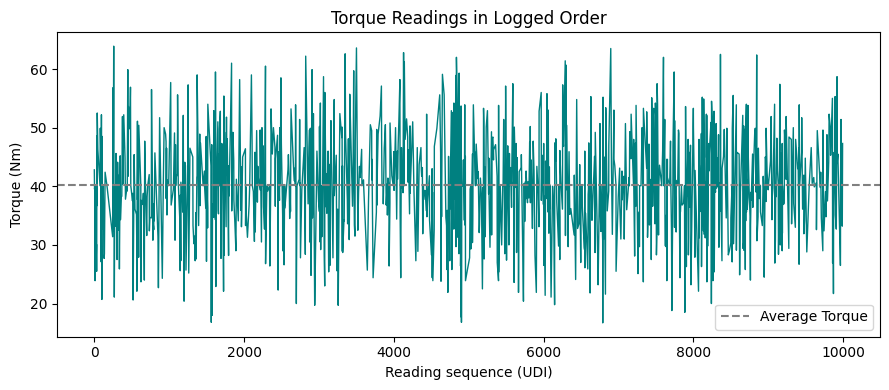

In [ ]:
df_sorted = df.sort_values('UDI')

plt.figure(figsize=(9,4))
plt.plot(df_sorted['UDI'], df_sorted['Torque'], color='teal', linewidth=1)
plt.axhline(df['Torque'].mean(), color='gray', linestyle='--', label='Average Torque')
plt.title('Torque Readings in Logged Order')
plt.xlabel('Reading sequence (UDI)')
plt.ylabel('Torque (Nm)')
plt.legend()
plt.tight_layout()
plt.show()


The dashed line marks the average. Notice how the readings bounce around that average
in a fairly steady band — this is what a well-behaved sensor reading normally looks
like. Later in this stage, we will use exactly this kind of pattern to help decide when
a reading looks unusual.


### Chart 2: A bar chart — does product Type affect the failure rate?


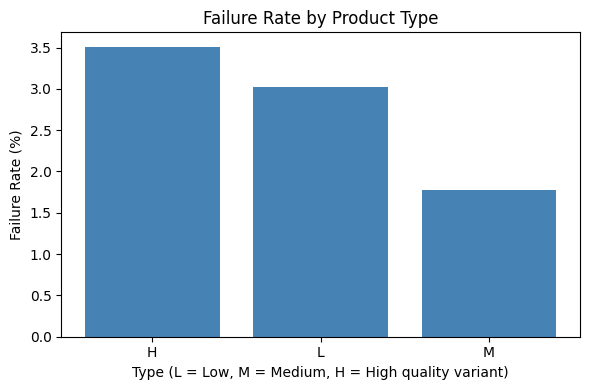

In [ ]:
failure_by_type = df.groupby('Type')['Failure'].mean() * 100

plt.figure(figsize=(6,4))
plt.bar(failure_by_type.index, failure_by_type.values, color='steelblue')
plt.title('Failure Rate by Product Type')
plt.xlabel('Type (L = Low, M = Medium, H = High quality variant)')
plt.ylabel('Failure Rate (%)')
plt.tight_layout()
plt.show()


### Chart 3: A grouped bar chart — comparing Torque and Tool Wear side by side

So far we have looked at one column at a time. A grouped bar chart lets us compare two
measurements together, for failed versus non-failed machines, in a single picture.


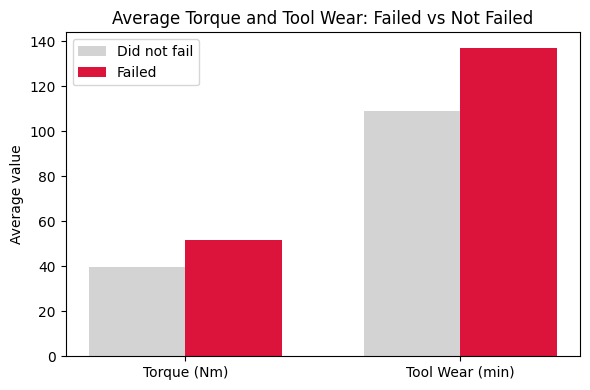

In [ ]:
recorded = df[df['ToolWearRecorded'] == 1]

failed_avg = [df[df['Failure']==1]['Torque'].mean(), recorded[recorded['Failure']==1]['ToolWear'].mean()]
normal_avg = [df[df['Failure']==0]['Torque'].mean(), recorded[recorded['Failure']==0]['ToolWear'].mean()]

labels = ['Torque (Nm)', 'Tool Wear (min)']
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, normal_avg, width, label='Did not fail', color='lightgray')
plt.bar(x + width/2, failed_avg, width, label='Failed', color='crimson')
plt.xticks(x, labels)
plt.title('Average Torque and Tool Wear: Failed vs Not Failed')
plt.ylabel('Average value')
plt.legend()
plt.tight_layout()
plt.show()


Both bars are clearly higher for machines that failed. This is our first strong clue:
failure seems to be linked to running with high torque, high tool wear, or both.


### Chart 4: A histogram — how is Tool Wear distributed?


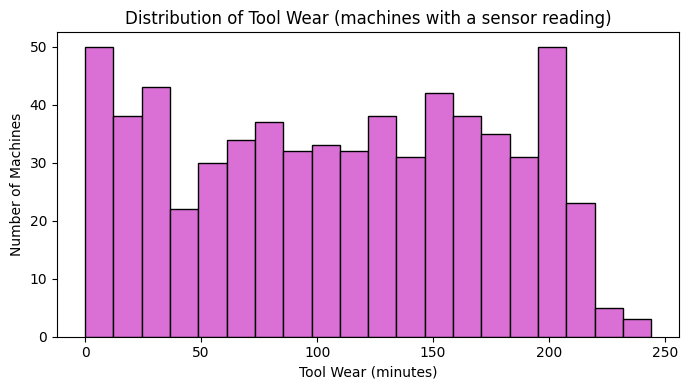

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(recorded['ToolWear'], bins=20, color='orchid', edgecolor='black')
plt.title('Distribution of Tool Wear (machines with a sensor reading)')
plt.xlabel('Tool Wear (minutes)')
plt.ylabel('Number of Machines')
plt.tight_layout()
plt.show()


### Chart 5: A scatter plot — do Torque and Tool Wear together predict failure?

A scatter plot places one dot per machine, positioned by two measurements at once. We
will also colour each dot by whether that machine failed, so we can see three things
in a single chart.


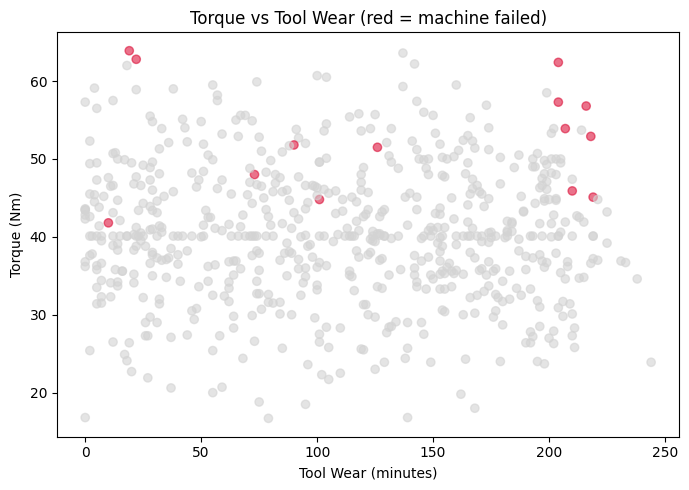

In [ ]:
plot_data = df[df['ToolWearRecorded'] == 1]
colors = plot_data['Failure'].map({0: 'lightgray', 1: 'crimson'})

plt.figure(figsize=(7,5))
plt.scatter(plot_data['ToolWear'], plot_data['Torque'], alpha=0.6, c=colors)
plt.title('Torque vs Tool Wear (red = machine failed)')
plt.xlabel('Tool Wear (minutes)')
plt.ylabel('Torque (Nm)')
plt.tight_layout()
plt.show()


Look at where the red dots sit. They are not scattered evenly across the chart — they
cluster towards the upper right, where both tool wear and torque are high. That
combination looks like our warning sign.


### Chart 6: Boxplots — confirming the pattern with numbers, not just a visual impression


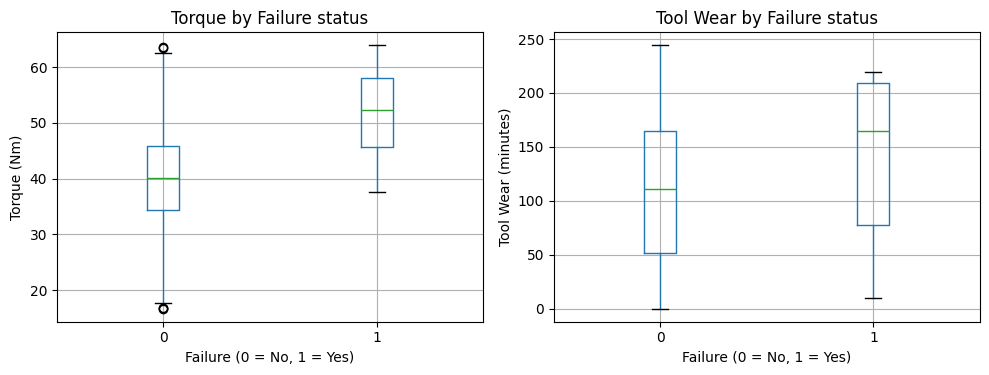

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

df.boxplot(column='Torque', by='Failure', ax=axes[0])
axes[0].set_title('Torque by Failure status')
axes[0].set_xlabel('Failure (0 = No, 1 = Yes)')
axes[0].set_ylabel('Torque (Nm)')

recorded.boxplot(column='ToolWear', by='Failure', ax=axes[1])
axes[1].set_title('Tool Wear by Failure status')
axes[1].set_xlabel('Failure (0 = No, 1 = Yes)')
axes[1].set_ylabel('Tool Wear (minutes)')

plt.suptitle('')
plt.tight_layout()
plt.show()


### Chart 7: A bar chart — what about temperature?

We have focused on Torque and Tool Wear so far. Let's check whether temperature shows
a similar pattern, or whether it looks like a weaker signal by comparison.


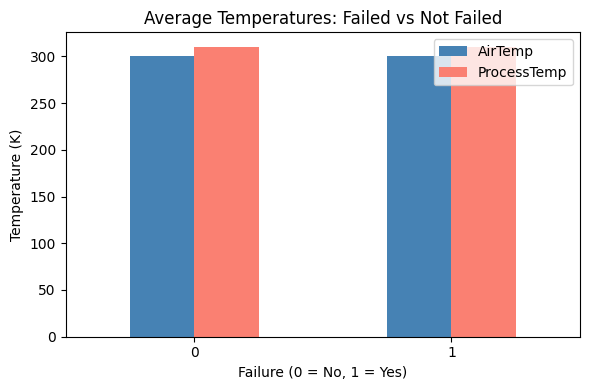

In [ ]:
temp_comparison = df.groupby('Failure')[['AirTemp', 'ProcessTemp']].mean()
temp_comparison.plot(kind='bar', figsize=(6,4), color=['steelblue', 'salmon'])
plt.title('Average Temperatures: Failed vs Not Failed')
plt.xlabel('Failure (0 = No, 1 = Yes)')
plt.ylabel('Temperature (K)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Compare the height difference here with the height difference we saw earlier for
Torque and Tool Wear. Temperature still shows some difference, but it is a much smaller
gap — a weaker signal than Torque and Tool Wear.


### Chart 8: A pie chart — what does our current fleet look like by Type?


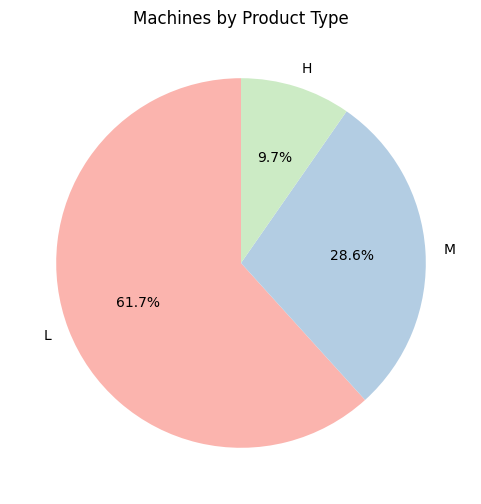

In [ ]:
type_counts = df['Type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        colors=plt.cm.Pastel1.colors, startangle=90)
plt.title('Machines by Product Type')
plt.show()


Try it yourself: using the same grouped-bar pattern from Chart 3, compare average
`RotSpeed` for failed versus non-failed machines. Does rotation speed look like a
strong signal, or a weak one?


In [ ]:
# Try it yourself here:



## Stage 10: Turning the Pattern Into an Action List

This is where we answer the plant manager's original question.

Across several charts, we consistently saw the same pattern: machines with both high
Torque and high Tool Wear are more likely to have failed. Let's turn that observation
into a simple, usable rule, and apply it to every machine currently in our log.


### Setting sensible thresholds

We do not want to guess a threshold out of thin air. Instead, we will base it on our
own data: we will look at the "normal" (non-failed) machines, and use a level that
75% of them stay below. Anything meaningfully above that, on both measurements at
once, is worth a closer look.


In [ ]:
torque_threshold = df[df['Failure'] == 0]['Torque'].quantile(0.75)
toolwear_threshold = recorded[recorded['Failure'] == 0]['ToolWear'].quantile(0.75)

print(f"Torque threshold: above {torque_threshold:.1f} Nm")
print(f"Tool Wear threshold: above {toolwear_threshold:.1f} minutes")


Torque threshold: above 45.8 Nm
Tool Wear threshold: above 165.0 minutes


In [ ]:
df['AtRisk'] = (
    (df['ToolWearRecorded'] == 1) &
    (df['Torque'] > torque_threshold) &
    (df['ToolWear'] > toolwear_threshold)
).astype(int)

at_risk_machines = df[df['AtRisk'] == 1].sort_values('Torque', ascending=False)
print(f"Machines flagged as high risk: {len(at_risk_machines)} out of {len(df)} total")
at_risk_machines[['UDI', 'ProductID', 'Type', 'Torque', 'ToolWear', 'Failure']].head(15)


Machines flagged as high risk: 42 out of 1178 total


,UDI,ProductID,Type,Torque,ToolWear,Failure
201,8847,M23706,M,62.4,204.0,1
868,2493,H31906,H,58.5,199.0,0
1109,6256,L53435,L,57.3,204.0,1
469,484,L47663,L,56.9,173.0,0
916,249,L47428,L,56.8,216.0,1
564,9894,M24753,M,55.3,166.0,0
791,9086,H38499,H,54.0,174.0,0
429,9415,L56594,L,53.9,207.0,1
880,5063,L52242,L,53.9,202.0,0
769,4899,H34312,H,53.7,214.0,0


Before trusting this rule, let's check it against reality: among the machines we
flagged, how many actually did fail, compared to the machines we did not flag? A useful
rule should show a much higher failure rate inside the flagged group.


In [ ]:
check = df[df['ToolWearRecorded'] == 1].groupby('AtRisk')['Failure'].mean() * 100
check.index = ['Not flagged', 'Flagged as at-risk']
check.name = 'Actual failure rate (%)'
check


,Actual failure rate (%)
Not flagged,1.322314
Flagged as at-risk,14.285714


Let's see this rule visually, drawn directly onto our earlier scatter plot.


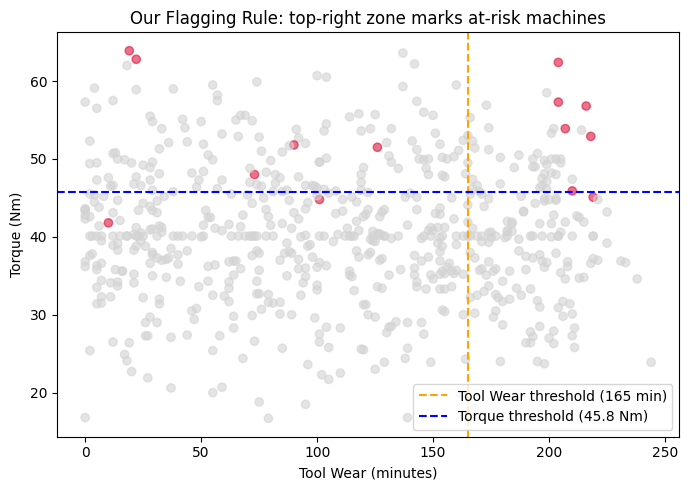

In [ ]:
plot_data = df[df['ToolWearRecorded'] == 1]
colors = plot_data['Failure'].map({0: 'lightgray', 1: 'crimson'})

plt.figure(figsize=(7,5))
plt.scatter(plot_data['ToolWear'], plot_data['Torque'], alpha=0.6, c=colors)
plt.axvline(toolwear_threshold, color='orange', linestyle='--',
            label=f'Tool Wear threshold ({toolwear_threshold:.0f} min)')
plt.axhline(torque_threshold, color='blue', linestyle='--',
            label=f'Torque threshold ({torque_threshold:.1f} Nm)')
plt.title('Our Flagging Rule: top-right zone marks at-risk machines')
plt.xlabel('Tool Wear (minutes)')
plt.ylabel('Torque (Nm)')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
at_risk_machines[['UDI', 'ProductID', 'Type', 'Torque', 'ToolWear']].to_excel(
    'machines_needing_inspection.xlsx', index=False)

print("Exported machines_needing_inspection.xlsx")
print()
print("Summary for the plant manager:")
print(f"  Readings analysed: {len(df)}")
print(f"  Machines flagged for inspection: {len(at_risk_machines)}")
print("  Flagged machines show a clearly higher failure rate than the rest of the fleet.")


Exported machines_needing_inspection.xlsx

Summary for the plant manager:
  Readings analysed: 1178
  Machines flagged for inspection: 42
  Flagged machines show a clearly higher failure rate than the rest of the fleet.


This is the outcome the plant manager originally asked for. We did not stop at making
charts — we used cleaning and visualization to find a genuine pattern, turned that
pattern into a simple rule, and produced a real, exportable list.

Worth keeping in mind: in a real project, a rule like this would usually be checked
much more thoroughly, often using a proper statistical model, before being trusted
fully. But the overall path we followed today — clean the data, visualize it, find the
pattern, turn it into a rule, export a decision-ready list — is the same path used in
professional predictive maintenance systems. The main difference is that a real system
would use a more sophisticated model in place of our simple threshold rule.


## Stage 11: Wrap-up and Assignment

### What we did today

```
Import   ->  bring the Excel file into pandas
Explore  ->  shape, info, describe
Clean    ->  missing values, duplicates, outliers, text checks
Export   ->  save the cleaned table
Visualize -> multiple charts, each aimed at one question
Act      ->  turn the pattern into a rule, and export a decision-ready list
```

That last step — turning a pattern into an action — is the part that is easy to skip
if you explore data question by question without a clear goal. Every chart we built
today existed to help us reach that final, usable list.

### Assignment: Apply the same thinking to a new problem

Choose a different manufacturing-related dataset — for example, energy consumption
logs, scrap or defect rate records, or inventory data.

This assignment is a written plan, not code. For your chosen dataset, write short
answers to the following:

1. **The decision.** What decision should this data help someone make? Who would act
   on your final output — a supervisor, a maintenance team, a planner?

2. **The six stages.** For each stage below, write what you expect to need:
   - Import — what format is the data in?
   - Explore — what columns do you expect, and what are you unsure about?
   - Clean — where might you expect missing values, duplicates, outliers, or messy
     text, and why, given this setting?
   - Visualize — which chart or charts would reveal the pattern that matters?
   - Act — what concrete, exportable output would you hand to a decision-maker?

3. **A simple sketch.** A short diagram or list showing your dataset moving through
   these stages, ending in a real action rather than only a chart.


## Quick Reference

| Task | Code |
|---|---|
| Read an Excel file | `pd.read_excel('file.xlsx')` |
| Shape of the data | `df.shape` |
| Column information | `df.info()` |
| Summary statistics | `df.describe()` |
| Count missing values | `df.isnull().sum()` |
| Fill missing values | `df['col'].fillna(value)` |
| Flag whether a value was recorded | `df['col'].notnull().astype(int)` |
| Count duplicate rows | `df.duplicated().sum()` |
| Remove duplicate rows | `df.drop_duplicates()` |
| Clean up text spacing and case | `df['col'].str.strip().str.upper()` |
| Compare two columns | `df[df['colA'] != df['colB']]` |
| Save to CSV or Excel | `df.to_csv(...)` or `df.to_excel(...)` |
| Group and average | `df.groupby('col')['target'].mean()` |
| Line chart | `plt.plot(x, y)` |
| Bar chart | `plt.bar(x, y)` |
| Histogram | `plt.hist(data, bins=n)` |
| Scatter plot | `plt.scatter(x, y)` |
| Boxplot by group | `df.boxplot(column='c', by='group')` |
| Pie chart | `plt.pie(values, labels=labels)` |
| Add a threshold line to a chart | `plt.axvline(x, ...)` or `plt.axhline(y, ...)` |

That is the end of today's session. Questions are welcome.
